# Student Performance Data Analysis
In this notebook, we will load our student dataset and analyze it using charts to find patterns.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read the CSV file we created
df = pd.read_csv('data/stud.csv')

# Step 2: Show the data table on the screen
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.6
1,female,group C,some college,standard,completed,69,90,88,82.3
2,male,group A,associate's degree,free/reduced,none,47,47,44,46.0
3,male,group C,some college,standard,none,76,78,75,76.3
4,female,group B,high school,standard,none,71,83,78,77.3


## 1. Checking Data Structure
Let's see how many rows and columns we have, and check if there are any missing values.

In [8]:
# Check rows and columns
print("Dataset Shape:", df.shape)

# Check data types and missing values
df.info()

Dataset Shape: (5, 9)
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5 non-null      str    
 1   race_ethnicity               5 non-null      str    
 2   parental_level_of_education  5 non-null      str    
 3   lunch                        5 non-null      str    
 4   test_preparation_course      5 non-null      str    
 5   math_score                   5 non-null      int64  
 6   reading_score                5 non-null      int64  
 7   writing_score                5 non-null      int64  
 8   average                      5 non-null      float64
dtypes: float64(1), int64(3), str(5)
memory usage: 492.0 bytes


## 1.2 Descriptive Statistics
Let's look at the statistical summary of our numerical columns to see the mean (average), minimum, and maximum scores.

# This gives us mean, std deviation, min, max, and percentiles for numerical columns
df.describe()

## 2. Univariate Analysis (Boxplots)
We will now draw boxplots to visually inspect the spread of 'writing score' and the overall 'average' score to see if there are any outliers.

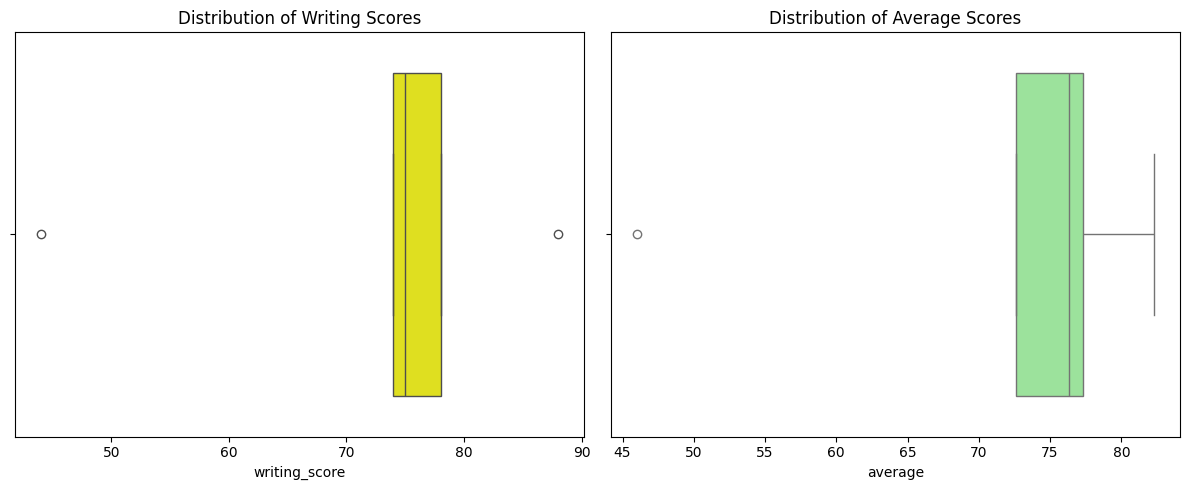

In [11]:
# Set up a wide screen area for two side-by-side charts
plt.figure(figsize=(12, 5))

# Chart 1: Boxplot for Writing Score
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='writing_score', color='yellow')
plt.title('Distribution of Writing Scores')

# Chart 2: Boxplot for Average Score
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='average', color='lightgreen')
plt.title('Distribution of Average Scores')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

In [10]:
print(df.columns)

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'average'],
      dtype='str')


## 3. Multivariate Analysis Using Pairplot
Let's see how all the numerical performance scores relate to each other, using gender as a color separator.

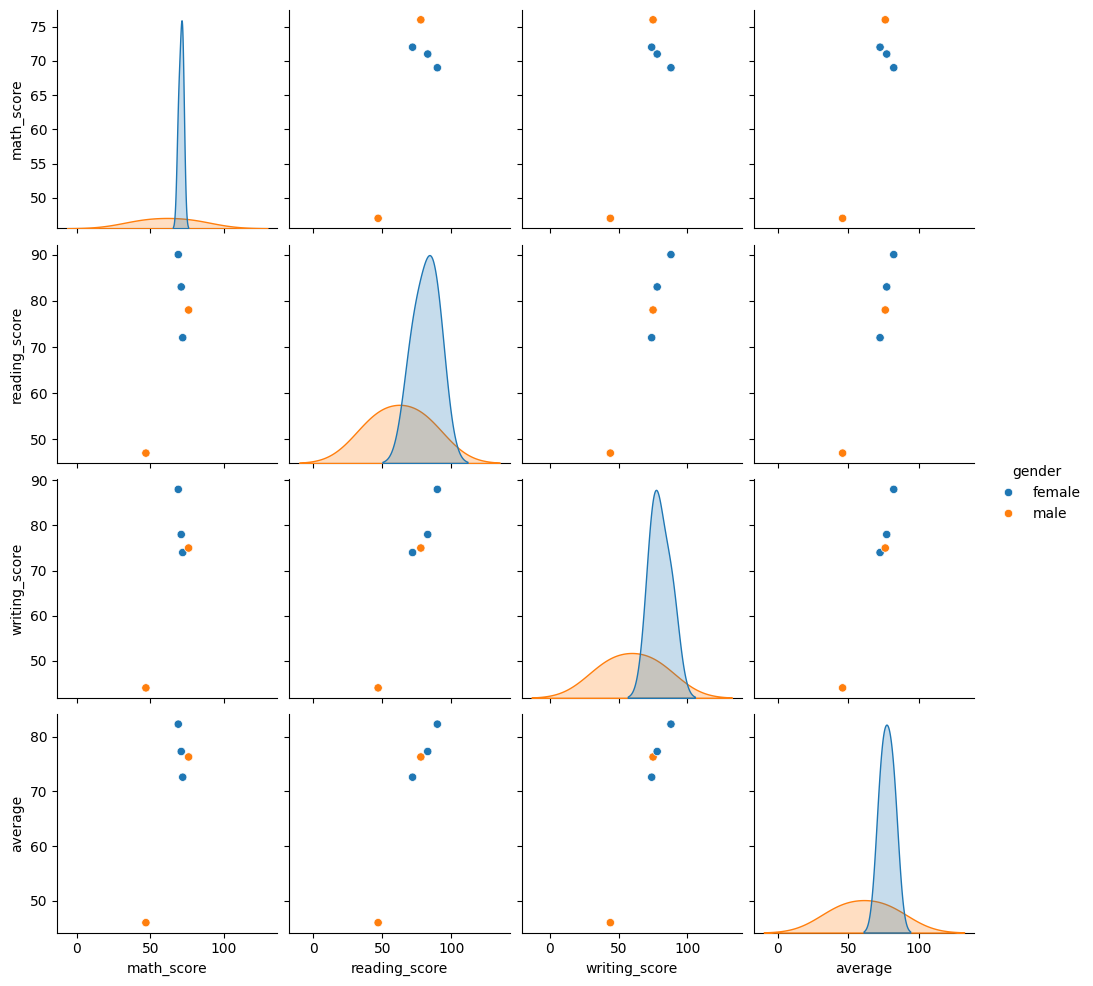

In [12]:
# Create a pairplot to compare all numerical scores side-by-side
sns.pairplot(df, hue='gender')
plt.show()

## 4. Final Insights & Conclusions
* **Correlations:** All score types show a strong, direct linear relationship with one another.
* **Next Phase:** The Exploratory Data Analysis is complete. The dataset has no missing values and is well-structured. We can now proceed to `2.MODEL TRAINING.ipynb`.

## 5. Preparing Data for Transformation
We will split our dataset into `X` (the features we use to predict) and `y` (the target variable we want to predict, which is the `average` score).

In [ ]:
# Drop the target column 'average' to create the features dataset (X)
X = df.drop(columns=['average'], axis=1)

# Keep only 'average' as our target dataset (y)
y = df['average']

print("Features (X) columns:", X.columns.tolist())
print("Target (y) column:", y.name)

## 6. Building the Column Transformer Pipeline
We will create a ColumnTransformer using 3 key preprocessors:
1. **SimpleImputer**: Handles missing values.
2. **StandardScaler**: Normalizes numerical scales.
3. **OneHotEncoder**: Converts text categories to numbers.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Separate your columns by their data types
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

# 2. Create a pipeline for Numerical features (Imputer + Scaler)
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# 3. Create a pipeline for Categorical features (Imputer + OneHotEncoder)
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", OneHotEncoder()),
        ("scaler", StandardScaler(with_mean=False))
    ]
)

# 4. Combine them together into the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipeline", num_pipeline, num_features),
        ("cat_pipeline", cat_pipeline, cat_features)
    ]
)

# 5. Transform your features dataset X
X_transformed = preprocessor.fit_transform(X)

print("Original shape of X:", X.shape)
print("Transformed shape of X:", X_transformed.shape)

ModuleNotFoundError: No module named 'sklearn'